# Descriptive Statistics & Table 1
**Study:** APOE ε4 × Hippocampal Volume × Cognitive Decline

Requires: `reports/ADNI_Baseline_Analysis.csv` and `reports/ADNI_Complete_Cases.csv` from `01_data_pipeline.ipynb`.

**Produces:**
- Table 1 by APOE ε4 dose
- APOE4 frequency bar chart
- Cognitive score distributions by APOE dose
- Hippocampal volume by APOE dose
- Missing data heatmap
- Diagnosis × APOE breakdown

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

BASE    = '/media/faizaan/4TB/1_DATA_PROJECTS/Projects/Multimodel_study'
REPORTS = os.path.join(BASE, 'reports')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
APOE_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
APOE_LABELS = {0: 'ε4 non-carrier (0)', 1: 'ε4 heterozygote (1)', 2: 'ε4 homozygote (2)'}

# Load processed data
baseline = pd.read_csv(os.path.join(REPORTS, 'ADNI_Baseline_Analysis.csv'))
complete = pd.read_csv(os.path.join(REPORTS, 'ADNI_Complete_Cases.csv'))

# Ensure numeric APOE4_DOSE
baseline['APOE4_DOSE'] = pd.to_numeric(baseline['APOE4_DOSE'], errors='coerce')
complete['APOE4_DOSE'] = pd.to_numeric(complete['APOE4_DOSE'], errors='coerce')

print(f'Baseline: {len(baseline)} subjects')
print(f'Complete (longitudinal): {complete["RID"].nunique()} subjects, {len(complete):,} obs')

Baseline: 2417 subjects
Complete (longitudinal): 2417 subjects, 11,793 obs


## 1. Table 1 — Baseline Characteristics by APOE ε4 Dose

In [30]:
from scipy.stats import f_oneway, chi2_contingency, kruskal

def stat_test_continuous(df, col, group_col='APOE4_DOSE'):
    """Kruskal-Wallis test across APOE doses"""
    groups = [df[df[group_col] == d][col].dropna() for d in [0, 1, 2]]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2: return np.nan
    _, p = kruskal(*groups)
    return p

def stat_test_categorical(df, col, group_col='APOE4_DOSE'):
    """Chi-squared test"""
    try:
        ct = pd.crosstab(df[group_col], df[col])
        _, p, _, _ = chi2_contingency(ct)
        return p
    except:
        return np.nan

def fmt_p(p):
    if pd.isna(p): return '—'
    if p < 0.001: return '<0.001'
    return f'{p:.3f}'

rows = []

# N per group
group_ns = {d: (baseline['APOE4_DOSE'] == d).sum() for d in [0, 1, 2]}

# Variables to include
specs = [
    ('N',             'n',          None),
    ('Age (yrs)',     'AGE',        'mean_sd'),
    ('Female, %',     'SEX',        'pct_female'),
    ('Education (yrs)', 'PTEDUCAT', 'mean_sd'),
    ('MMSE',          'MMSCORE',    'mean_sd'),
    ('CDR-SB',        'CDRSB',      'mean_sd'),
    ('ADAS-Cog13',    'ADAS_COG',   'mean_sd'),
    ('Hippo (mm³)',   'HIPPO_TOTAL','mean_sd'),
    ('Hippo/ICV',     'HIPPO_ICV_ADJ','mean_sd'),
    ('GDS',           'GDTOTAL',    'mean_sd'),
    ('NPI-Q',         'NPISCORE',   'mean_sd'),
    ('Diagnosis: CN %','BL_DX_LABEL','pct_cn'),
    ('Diagnosis: MCI %','BL_DX_LABEL','pct_mci'),
    ('Diagnosis: AD %','BL_DX_LABEL','pct_ad'),
]

for label, col, fmt in specs:
    row = {'Variable': label}
    
    if fmt is None:  # N
        for d in [0, 1, 2]: row[f'APOE_{d}'] = group_ns[d]
        row['Overall'] = len(baseline)
        row['p'] = '—'
    elif col not in baseline.columns:
        for d in [0, 1, 2]: row[f'APOE_{d}'] = 'N/A'
        row['Overall'] = 'N/A'; row['p'] = '—'
    elif fmt == 'mean_sd':
        for d in [0, 1, 2]:
            sub = baseline[baseline['APOE4_DOSE'] == d][col].dropna()
            if len(sub) > 0:
                row[f'APOE_{d}'] = f'{sub.mean():.1f} ({sub.std():.1f})'
            else:
                row[f'APOE_{d}'] = 'N/A'
        row['Overall'] = f'{baseline[col].mean():.1f} ({baseline[col].std():.1f})'
        row['p'] = fmt_p(stat_test_continuous(baseline, col))
    elif fmt == 'pct_female':
        for d in [0, 1, 2]:
            sub = baseline[baseline['APOE4_DOSE'] == d]['SEX'].dropna()
            pct = (sub == 'Female').mean() * 100 if len(sub) > 0 else np.nan
            row[f'APOE_{d}'] = f'{pct:.1f}' if not np.isnan(pct) else 'N/A'
        pct_all = (baseline['SEX'] == 'Female').mean() * 100
        row['Overall'] = f'{pct_all:.1f}'
        row['p'] = fmt_p(stat_test_categorical(baseline, 'SEX'))
    elif fmt in ('pct_cn', 'pct_mci', 'pct_ad'):
        dx_map = {'pct_cn': 'CN', 'pct_mci': 'MCI', 'pct_ad': 'AD'}
        dx = dx_map[fmt]
        for d in [0, 1, 2]:
            sub = baseline[baseline['APOE4_DOSE'] == d]['BL_DX_LABEL'].dropna()
            pct = (sub == dx).mean() * 100 if len(sub) > 0 else np.nan
            row[f'APOE_{d}'] = f'{pct:.1f}' if not np.isnan(pct) else 'N/A'
        pct_all = (baseline['BL_DX_LABEL'] == dx).mean() * 100
        row['Overall'] = f'{pct_all:.1f}'
        if fmt == 'pct_cn': row['p'] = fmt_p(stat_test_categorical(baseline, 'BL_DX_LABEL'))
        else: row['p'] = ''
    
    rows.append(row)

table1 = pd.DataFrame(rows)
table1.columns = ['Variable',
                  f'0 alleles (N={group_ns[0]})',
                  f'1 allele (N={group_ns[1]})',
                  f'2 alleles (N={group_ns[2]})',
                  f'Overall (N={len(baseline)})',
                  'p-value']

pd.set_option('display.max_colwidth', 30)
print('TABLE 1: Baseline Characteristics by APOE ε4 Dose')
print('(Continuous: mean (SD); p from Kruskal-Wallis; categorical: %, p from χ²)')
print()
print(table1.to_string(index=False))

# Save
table1.to_csv(os.path.join(REPORTS, 'ADNI_Table1_Characteristics.csv'), index=False)
print('\n✓ Saved: ADNI_Table1_Characteristics.csv')

TABLE 1: Baseline Characteristics by APOE ε4 Dose
(Continuous: mean (SD); p from Kruskal-Wallis; categorical: %, p from χ²)

        Variable 0 alleles (N=1322) 1 allele (N=870) 2 alleles (N=225) Overall (N=2417) p-value
               N               1322              870               225             2417       —
       Age (yrs)         73.3 (7.6)       72.7 (7.0)        70.6 (7.0)       72.9 (7.4)  <0.001
       Female, %               48.4             48.2              44.5             46.9   0.567
 Education (yrs)         16.2 (2.7)       15.9 (2.8)        15.9 (2.6)       16.1 (2.7)   0.010
            MMSE         27.9 (2.4)       27.0 (2.8)        25.9 (3.0)       27.4 (2.7)  <0.001
          CDR-SB          1.1 (1.6)        1.8 (1.8)         2.4 (2.0)        1.5 (1.8)  <0.001
      ADAS-Cog13         13.7 (8.6)      17.8 (10.1)        20.8 (9.4)       15.8 (9.6)  <0.001
     Hippo (mm³)     4471.5 (721.5)   4444.1 (856.4)    4272.5 (811.6)   4443.1 (782.7)  <0.001
       Hipp

## 2. APOE4 Frequency Plot

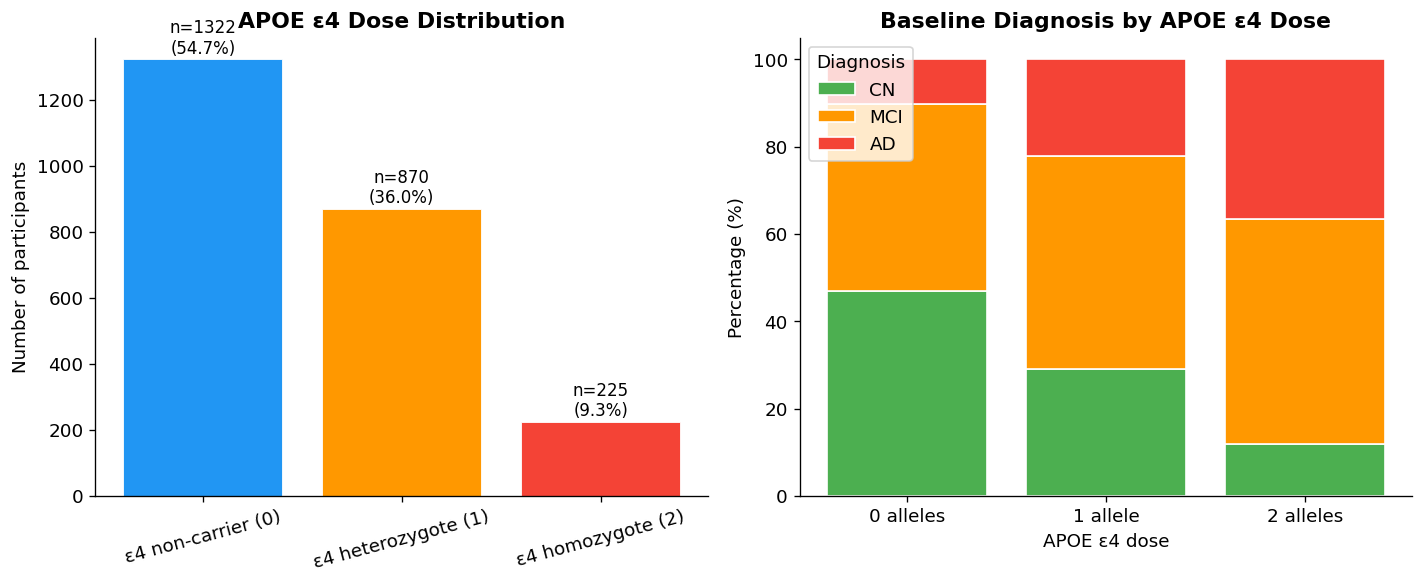

✓ Saved: Fig1_APOE_Distribution.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: APOE dose counts
ax = axes[0]
dose_counts = baseline['APOE4_DOSE'].value_counts().sort_index()
bars = ax.bar([APOE_LABELS[d] for d in dose_counts.index],
              dose_counts.values,
              color=[APOE_COLORS[d] for d in dose_counts.index],
              edgecolor='white', linewidth=0.5)
for bar, n in zip(bars, dose_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'n={n}\n({n/len(baseline)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of participants')
ax.set_title('APOE ε4 Dose Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=15)

# Right: Stacked diagnosis by APOE dose
ax = axes[1]
if 'BL_DX_LABEL' in baseline.columns:
    ct = pd.crosstab(baseline['APOE4_DOSE'], baseline['BL_DX_LABEL'], normalize='index') * 100
    ct = ct.reindex(columns=[c for c in ['CN', 'MCI', 'AD'] if c in ct.columns])
    dx_colors = {'CN': '#4CAF50', 'MCI': '#FF9800', 'AD': '#F44336'}
    bottom = np.zeros(len(ct))
    for dx in ct.columns:
        ax.bar(ct.index, ct[dx], bottom=bottom,
               label=dx, color=dx_colors.get(dx, 'grey'), edgecolor='white')
        bottom += ct[dx].values
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0 alleles', '1 allele', '2 alleles'])
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('APOE ε4 dose')
    ax.set_title('Baseline Diagnosis by APOE ε4 Dose', fontweight='bold')
    ax.legend(loc='upper left', title='Diagnosis')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'Fig1_APOE_Distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: Fig1_APOE_Distribution.png')

## 3. Cognitive Scores by APOE Dose

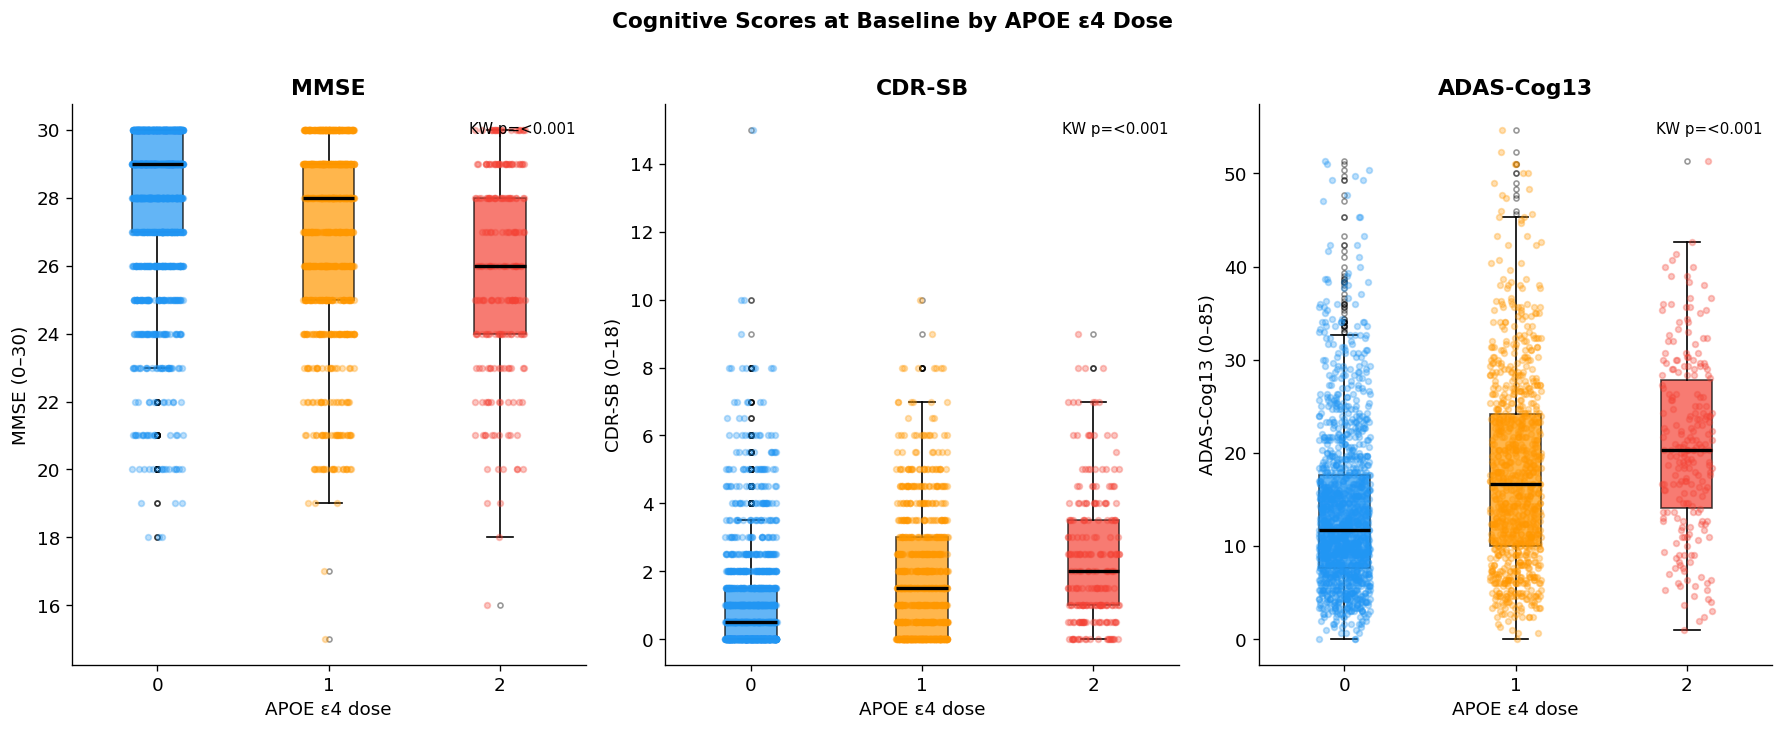

✓ Saved: Fig2_Cognition_by_APOE.png


In [32]:
cog_vars = [('MMSCORE', 'MMSE (0–30)', False),
            ('CDRSB',   'CDR-SB (0–18)', True),
            ('ADAS_COG','ADAS-Cog13 (0–85)', True)]

available = [(v, l, h) for v, l, h in cog_vars if v in baseline.columns]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 6))
    if len(available) == 1: axes = [axes]
    
    for ax, (var, label, higher_worse) in zip(axes, available):
        data_list = [baseline[baseline['APOE4_DOSE']==d][var].dropna() for d in [0,1,2]]
        positions = [0, 1, 2]
        
        bp = ax.boxplot(data_list, positions=positions, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
        for patch, d in zip(bp['boxes'], [0, 1, 2]):
            patch.set_facecolor(APOE_COLORS[d])
            patch.set_alpha(0.7)
        
        # Add individual points (jittered)
        for i, (data, d) in enumerate(zip(data_list, [0, 1, 2])):
            jitter = np.random.uniform(-0.15, 0.15, len(data))
            ax.scatter(i + jitter, data, alpha=0.3, s=12,
                       color=APOE_COLORS[d], zorder=2)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(['0', '1', '2'])
        ax.set_xlabel('APOE ε4 dose')
        ax.set_ylabel(label)
        ax.set_title(label.split(' ')[0], fontweight='bold')
        
        # Kruskal-Wallis p-value
        valid = [d for d in data_list if len(d) > 0]
        if len(valid) >= 2:
            _, p = stats.kruskal(*valid)
            ax.text(0.98, 0.97, f'KW p={fmt_p(p)}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9)
    
    plt.suptitle('Cognitive Scores at Baseline by APOE ε4 Dose', y=1.01, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'Fig2_Cognition_by_APOE.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: Fig2_Cognition_by_APOE.png')
else:
    print('No cognitive variables found in baseline data')

## 4. Hippocampal Volume by APOE Dose

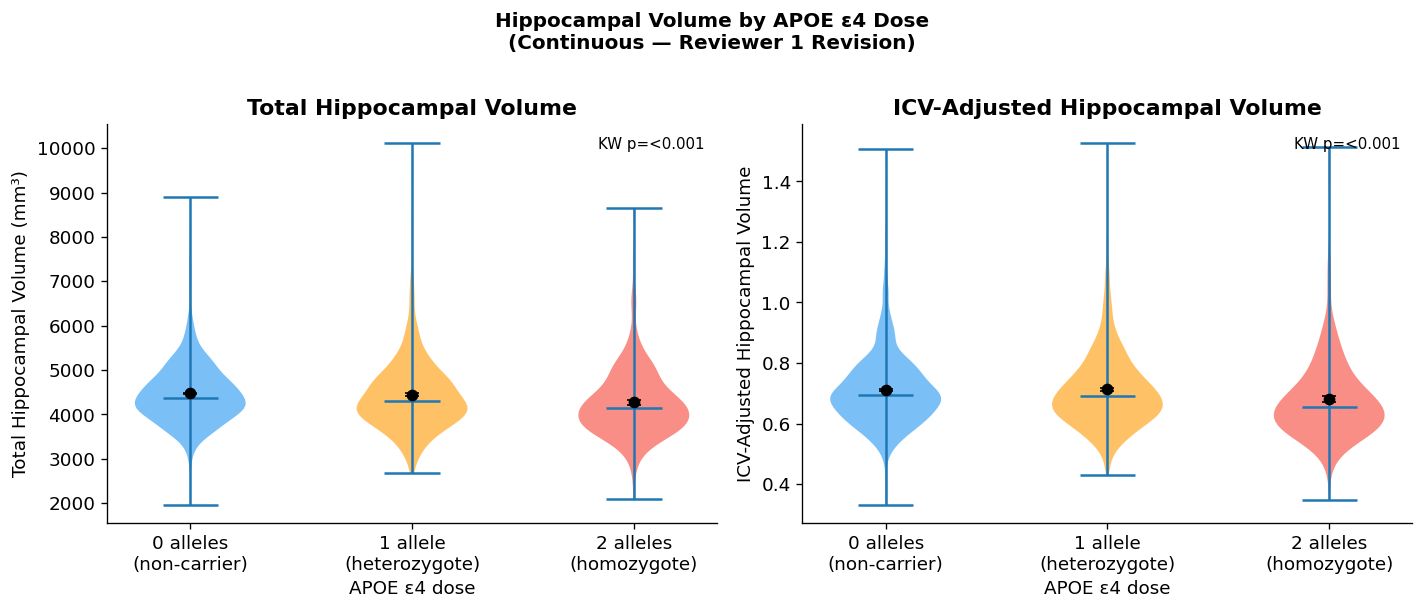

✓ Saved: Fig3_Hippocampus_by_APOE.png


In [33]:
if 'HIPPO_TOTAL' in baseline.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for ax, (var, label) in zip(axes, [
        ('HIPPO_TOTAL', 'Total Hippocampal Volume (mm³)'),
        ('HIPPO_ICV_ADJ', 'ICV-Adjusted Hippocampal Volume')
    ]):
        if var not in baseline.columns:
            ax.text(0.5, 0.5, f'{var} not available', transform=ax.transAxes, ha='center')
            continue
        
        data_list = [baseline[baseline['APOE4_DOSE']==d][var].dropna() for d in [0,1,2]]
        
        # Violin plot
        parts = ax.violinplot(data_list, positions=[0,1,2], showmedians=True)
        for i, (pc, d) in enumerate(zip(parts['bodies'], [0,1,2])):
            pc.set_facecolor(APOE_COLORS[d])
            pc.set_alpha(0.6)
        
        # Overlay means ± SE
        for i, (data, d) in enumerate(zip(data_list, [0, 1, 2])):
            if len(data) > 0:
                ax.errorbar(i, data.mean(), yerr=data.sem(),
                            fmt='o', color='black', zorder=5, capsize=4)
        
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['0 alleles\n(non-carrier)', '1 allele\n(heterozygote)', '2 alleles\n(homozygote)'])
        ax.set_xlabel('APOE ε4 dose')
        ax.set_ylabel(label)
        ax.set_title(label.split(' (')[0], fontweight='bold')
        
        valid = [d for d in data_list if len(d) > 0]
        if len(valid) >= 2:
            _, p = stats.kruskal(*valid)
            ax.text(0.98, 0.97, f'KW p={fmt_p(p)}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9)
    
    plt.suptitle('Hippocampal Volume by APOE ε4 Dose\n(Continuous — Reviewer 1 Revision)',
                 y=1.01, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'Fig3_Hippocampus_by_APOE.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: Fig3_Hippocampus_by_APOE.png')
else:
    print('Hippocampal volume not available in baseline data')

## 5. Longitudinal Cognitive Trajectories (Preview)

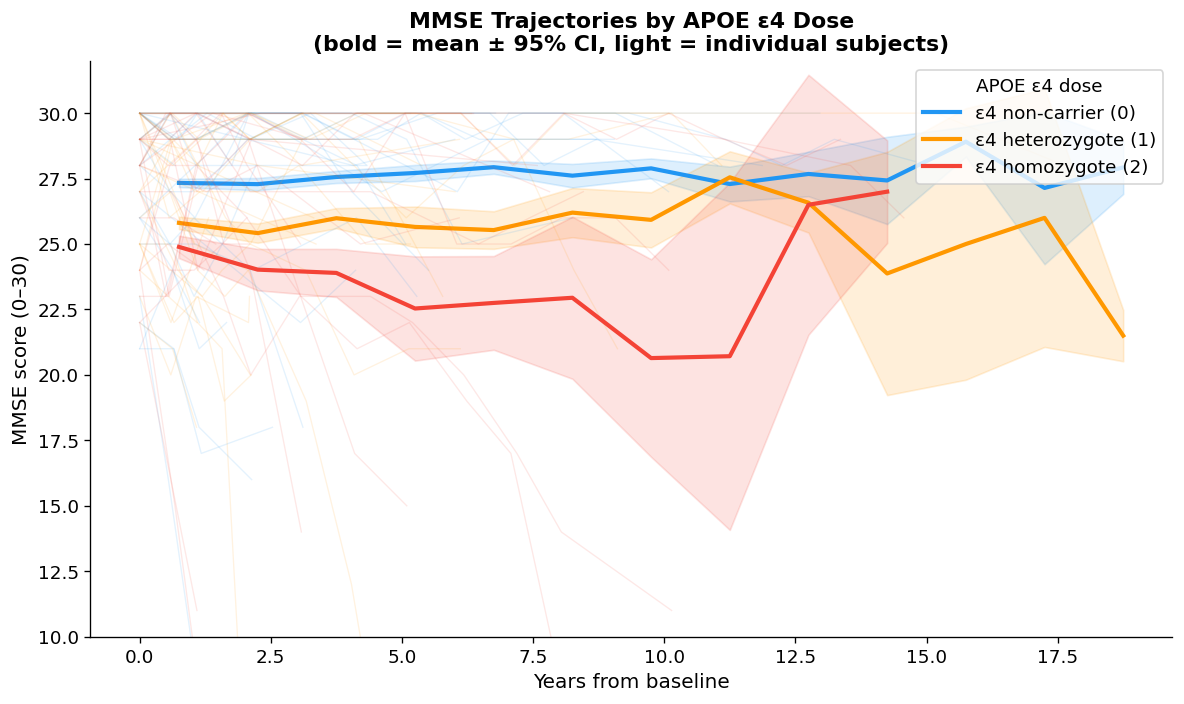

✓ Saved: Fig4_MMSE_Trajectories_Preview.png


In [34]:
if 'YEARS_FROM_BL' in complete.columns and 'MMSCORE' in complete.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for dose in [0, 1, 2]:
        sub = complete[complete['APOE4_DOSE'] == dose].dropna(subset=['YEARS_FROM_BL', 'MMSCORE'])
        if len(sub) == 0: continue
        
        # Sample 30 subjects for spaghetti
        sampled_rids = np.random.choice(sub['RID'].unique(),
                                         min(30, sub['RID'].nunique()), replace=False)
        for rid in sampled_rids:
            s = sub[sub['RID'] == rid].sort_values('YEARS_FROM_BL')
            ax.plot(s['YEARS_FROM_BL'], s['MMSCORE'],
                    color=APOE_COLORS[dose], alpha=0.12, linewidth=0.8)
        
        # Mean trajectory (binned)
        sub2 = sub.copy()
        sub2['time_bin'] = pd.cut(sub2['YEARS_FROM_BL'], bins=np.arange(0, 20, 1.5))
        traj = sub2.groupby('time_bin')['MMSCORE'].agg(['mean', 'sem']).reset_index()
        traj['mid'] = traj['time_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)
        traj = traj.dropna(subset=['mid'])
        ax.plot(traj['mid'], traj['mean'],
                color=APOE_COLORS[dose], linewidth=2.5,
                label=APOE_LABELS[dose])
        ax.fill_between(traj['mid'],
                         traj['mean'] - 1.96*traj['sem'],
                         traj['mean'] + 1.96*traj['sem'],
                         color=APOE_COLORS[dose], alpha=0.15)
    
    ax.set_xlabel('Years from baseline', fontsize=12)
    ax.set_ylabel('MMSE score (0–30)', fontsize=12)
    ax.set_title('MMSE Trajectories by APOE ε4 Dose\n(bold = mean ± 95% CI, light = individual subjects)',
                 fontweight='bold')
    ax.legend(title='APOE ε4 dose', loc='upper right')
    ax.set_ylim(10, 32)
    ax.invert_yaxis() if False else None  # MMSE: higher = better, no invert
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'Fig4_MMSE_Trajectories_Preview.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: Fig4_MMSE_Trajectories_Preview.png')

## 6. Missing Data Heatmap

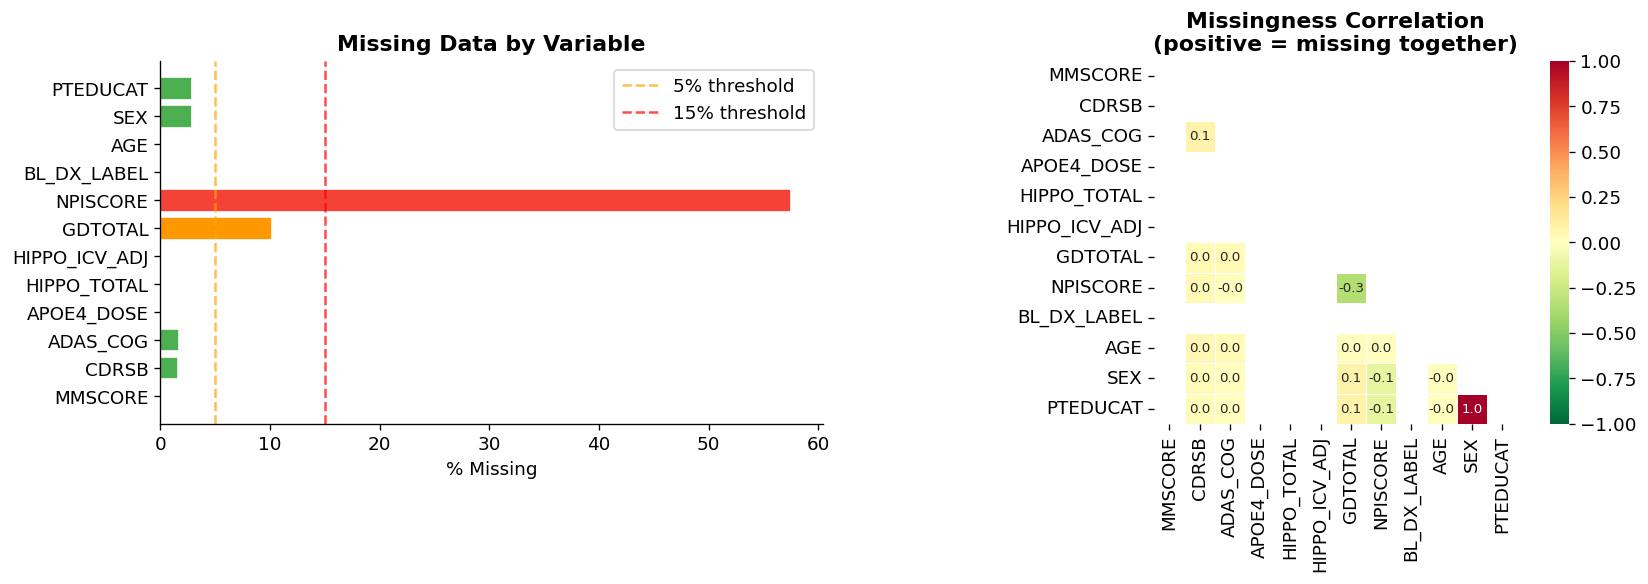

✓ Saved: Fig5_Missing_Data.png


In [35]:
key_vars = ['MMSCORE', 'CDRSB', 'ADAS_COG', 'APOE4_DOSE',
            'HIPPO_TOTAL', 'HIPPO_ICV_ADJ', 'GDTOTAL', 'NPISCORE',
            'BL_DX_LABEL', 'AGE', 'SEX', 'PTEDUCAT']
avail = [v for v in key_vars if v in complete.columns]

miss_data = complete[avail].isna().astype(int)
miss_pct  = miss_data.mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing %
ax = axes[0]
colors = ['#F44336' if p > 20 else '#FF9800' if p > 5 else '#4CAF50' for p in miss_pct]
ax.barh(miss_pct.index, miss_pct.values, color=colors, edgecolor='white')
ax.axvline(5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
ax.axvline(15, color='red', linestyle='--', alpha=0.7, label='15% threshold')
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Variable', fontweight='bold')
ax.legend()

# Correlation of missingness
ax = axes[1]
miss_corr = miss_data.corr()
mask = np.triu(np.ones_like(miss_corr, dtype=bool))
sns.heatmap(miss_corr, mask=mask, ax=ax,
            cmap='RdYlGn_r', vmin=-1, vmax=1,
            annot=True, fmt='.1f', annot_kws={'size': 8},
            square=True, linewidths=0.5)
ax.set_title('Missingness Correlation\n(positive = missing together)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'Fig5_Missing_Data.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: Fig5_Missing_Data.png')

## 7. Hippocampus–Cognition Scatter by APOE

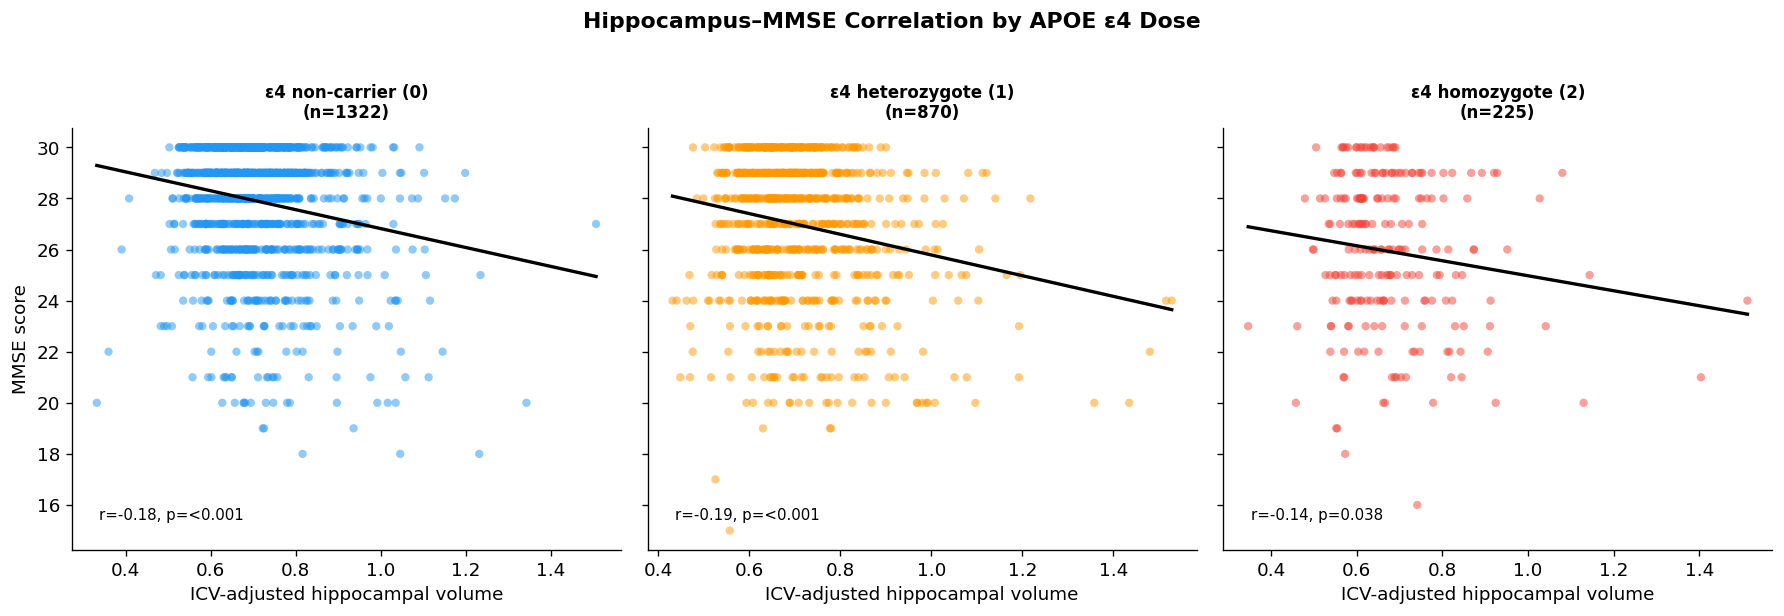

✓ Saved: Fig6_Hippo_MMSE_Scatter.png


In [36]:
if 'HIPPO_ICV_ADJ' in baseline.columns and 'MMSCORE' in baseline.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    
    for ax, dose in zip(axes, [0, 1, 2]):
        sub = baseline[baseline['APOE4_DOSE'] == dose].dropna(subset=['HIPPO_ICV_ADJ', 'MMSCORE'])
        if len(sub) < 3:
            ax.text(0.5, 0.5, f'n={len(sub)} (insufficient)', transform=ax.transAxes, ha='center')
            continue
        
        ax.scatter(sub['HIPPO_ICV_ADJ'], sub['MMSCORE'],
                   color=APOE_COLORS[dose], alpha=0.5, s=25, edgecolors='none')
        
        # Regression line
        slope, intercept, r, p, se = stats.linregress(sub['HIPPO_ICV_ADJ'], sub['MMSCORE'])
        x_range = np.linspace(sub['HIPPO_ICV_ADJ'].min(), sub['HIPPO_ICV_ADJ'].max(), 100)
        ax.plot(x_range, slope*x_range + intercept, color='black', linewidth=2)
        
        ax.set_title(f'{APOE_LABELS[dose]}\n(n={len(sub)})', fontsize=10, fontweight='bold')
        ax.set_xlabel('ICV-adjusted hippocampal volume')
        if dose == 0: ax.set_ylabel('MMSE score')
        ax.text(0.05, 0.07, f'r={r:.2f}, p={"<0.001" if p<0.001 else f"{p:.3f}"}',
                transform=ax.transAxes, fontsize=9)
    
    plt.suptitle('Hippocampus–MMSE Correlation by APOE ε4 Dose', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, 'Fig6_Hippo_MMSE_Scatter.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved: Fig6_Hippo_MMSE_Scatter.png')

## Summary

In [37]:
print('DESCRIPTIVE ANALYSIS COMPLETE')
print('='*50)
print(f'Baseline sample: {len(baseline)} subjects')
print(f'Longitudinal: {complete["RID"].nunique()} subjects, {len(complete):,} observations')
print()
print('Files saved to reports/:')
for f in sorted(os.listdir(REPORTS)):
    size = os.path.getsize(os.path.join(REPORTS, f)) / 1024
    print(f'  {f:<45} {size:>8.1f} KB')

DESCRIPTIVE ANALYSIS COMPLETE
Baseline sample: 2417 subjects
Longitudinal: 2417 subjects, 11,793 observations

Files saved to reports/:
  ADNI_Baseline_Analysis.csv                       565.7 KB
  ADNI_Complete_Cases.csv                         2945.4 KB
  ADNI_Data_Quality_Report.txt                       1.1 KB
  ADNI_Longitudinal_Analysis.csv                  2886.3 KB
  ADNI_Master_Longitudinal.csv                    3340.6 KB
  ADNI_Table1_Characteristics.csv                    0.8 KB
  Cox_PH_Results.csv                                 1.3 KB
  Fig1_APOE_Distribution.png                        96.7 KB
  Fig2_Cognition_by_APOE.png                       320.3 KB
  Fig3_Hippocampus_by_APOE.png                     119.4 KB
  Fig4_MMSE_Trajectories_Preview.png               293.3 KB
  Fig5_Missing_Data.png                            152.0 KB
  Fig6_Hippo_MMSE_Scatter.png                      190.5 KB
  Fig7_KaplanMeier.png                             115.1 KB
  Fig8_Cox_HazardRatios.